In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [2]:
data = {
    'Word_Frequency': [2, 5, 8, 3, 10, 12, 1, 4, 9, 15, 2, 11],
    'Message_Length': [20, 35, 50, 25, 60, 70, 15, 30, 55, 80, 18, 65],
    'Spam': [0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1]
}

df = pd.DataFrame(data)

print(df)

    Word_Frequency  Message_Length  Spam
0                2              20     0
1                5              35     0
2                8              50     1
3                3              25     0
4               10              60     1
5               12              70     1
6                1              15     0
7                4              30     0
8                9              55     1
9               15              80     1
10               2              18     0
11              11              65     1


In [3]:
print("Dataset Shape:", df.shape)

print("\nChecking for null values:")
print(df.isnull().sum())

print("\nDataset:")
print(df)

Dataset Shape: (12, 3)

Checking for null values:
Word_Frequency    0
Message_Length    0
Spam              0
dtype: int64

Dataset:
    Word_Frequency  Message_Length  Spam
0                2              20     0
1                5              35     0
2                8              50     1
3                3              25     0
4               10              60     1
5               12              70     1
6                1              15     0
7                4              30     0
8                9              55     1
9               15              80     1
10               2              18     0
11              11              65     1


In [4]:
X = df[['Word_Frequency', 'Message_Length']]
y = df['Spam']

print("Independent Variables:")
print(X)

print("\nDependent Variable:")
print(y)

Independent Variables:
    Word_Frequency  Message_Length
0                2              20
1                5              35
2                8              50
3                3              25
4               10              60
5               12              70
6                1              15
7                4              30
8                9              55
9               15              80
10               2              18
11              11              65

Dependent Variable:
0     0
1     0
2     1
3     0
4     1
5     1
6     0
7     0
8     1
9     1
10    0
11    1
Name: Spam, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=5
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (8, 2)
Testing Data: (4, 2)


In [6]:
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

print("Data standardized successfully.")

Data standardized successfully.


In [7]:
model = SVC(kernel='rbf', random_state=0)

model.fit(X_train, y_train)

print("SVM Model trained successfully.")

SVM Model trained successfully.


In [8]:
y_pred = model.predict(X_test)

print("Actual Values:")
print(y_test.values)

print("\nPredicted Values:")
print(y_pred)

Actual Values:
[0 1 1 1]

Predicted Values:
[0 1 1 1]


In [9]:
conf_mat = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(conf_mat)

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy Score:", accuracy)
print("Accuracy in Percentage:", int(accuracy * 100), "%")

Confusion Matrix:
[[1 0]
 [0 3]]

Accuracy Score: 1.0
Accuracy in Percentage: 100 %


In [10]:
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Not Spam', 'Spam']
))

Classification Report:
              precision    recall  f1-score   support

    Not Spam       1.00      1.00      1.00         1
        Spam       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



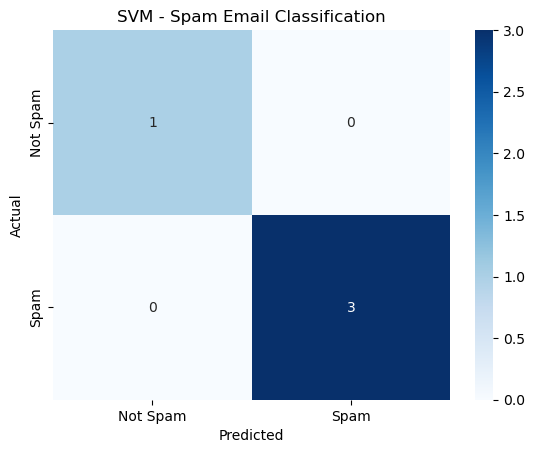

In [11]:
import seaborn as sns

sns.heatmap(
    conf_mat,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Spam', 'Spam'],
    yticklabels=['Not Spam', 'Spam']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM - Spam Email Classification")
plt.show()

In [13]:
word_frequency = float(input("Enter word frequency: "))
message_length = float(input("Enter message length: "))

new_email = pd.DataFrame(
    [[word_frequency, message_length]],
    columns=['Word_Frequency', 'Message_Length']
)

new_email_scaled = sc.transform(new_email)

prediction = model.predict(new_email_scaled)

if prediction[0] == 1:
    print("Prediction: Spam")
else:
    print("Prediction: Not Spam")

Enter word frequency:  15
Enter message length:  50


Prediction: Spam
